In [1]:
import pandas as pd
import matplotlib.pyplot as plt

https://data.mendeley.com/datasets/574v66hf2v/1

# Collecting data

In [2]:
df = pd.read_csv("../datasets/PRDECT-ID Dataset.csv")
df.head()

,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,Positive,Happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,Happy


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Category         5400 non-null   str    
 1   Product Name     5400 non-null   str    
 2   Location         5400 non-null   str    
 3   Price            5400 non-null   int64  
 4   Overall Rating   5400 non-null   float64
 5   Number Sold      5400 non-null   int64  
 6   Total Review     5400 non-null   int64  
 7   Customer Rating  5400 non-null   int64  
 8   Customer Review  5400 non-null   str    
 9   Sentiment        5400 non-null   str    
 10  Emotion          5400 non-null   str    
dtypes: float64(1), int64(4), str(6)
memory usage: 464.2 KB


# SPLITTING DATASET

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
strat_train_set, strat_test_set = train_test_split(df, test_size=0.2, 
random_state=42, stratify=df["Category"])

In [6]:
print("stratified test set")
print(strat_test_set["Category"].value_counts() / len(strat_test_set))


stratified test set
Category
Phones and Tablets          0.037037
Office & Stationery         0.037037
Other Products              0.037037
Muslim Fashion              0.037037
Electronics                 0.037037
Movies and Music            0.037037
Food and Drink              0.037037
Computers and Laptops       0.037037
Toys and Hobbies            0.037037
Gaming                      0.037037
Carpentry                   0.037037
Body Care                   0.037037
Animal Care                 0.037037
Kids and Baby Fashion       0.037037
Men's Fashion               0.037037
Automotive                  0.037037
Sport                       0.037037
Party Supplies and Craft    0.037037
Household                   0.037037
Beauty                      0.037037
Camera                      0.037037
Women's Fashion             0.037037
Health                      0.037037
Kitchen                     0.037037
Mother and Baby             0.037037
Books                       0.037037
Precious 

In [7]:
print(strat_test_set["Category"].value_counts() / len(strat_test_set))

Category
Phones and Tablets          0.037037
Office & Stationery         0.037037
Other Products              0.037037
Muslim Fashion              0.037037
Electronics                 0.037037
Movies and Music            0.037037
Food and Drink              0.037037
Computers and Laptops       0.037037
Toys and Hobbies            0.037037
Gaming                      0.037037
Carpentry                   0.037037
Body Care                   0.037037
Animal Care                 0.037037
Kids and Baby Fashion       0.037037
Men's Fashion               0.037037
Automotive                  0.037037
Sport                       0.037037
Party Supplies and Craft    0.037037
Household                   0.037037
Beauty                      0.037037
Camera                      0.037037
Women's Fashion             0.037037
Health                      0.037037
Kitchen                     0.037037
Mother and Baby             0.037037
Books                       0.037037
Precious Metal              0

# EDA

In [8]:
import copy

In [9]:
df.describe()

,Price,Overall Rating,Number Sold,Total Review,Customer Rating
count,5.400000e+03,5400.000000,5400.000000,5400.000000,5400.000000
mean,2.386961e+05,4.854389,15961.951852,2168.645556,3.087037
std,8.016337e+05,0.108259,74201.913338,2915.666035,1.766258
min,1.000000e+02,4.100000,9.000000,4.000000,1.000000
25%,2.000000e+04,4.800000,1630.000000,576.000000,1.000000
50%,5.990000e+04,4.900000,3794.500000,1192.000000,3.000000
75%,1.500000e+05,4.900000,9707.000000,2582.000000,5.000000
max,1.539900e+07,5.000000,1000000.000000,24500.000000,5.000000


In [10]:
df_eda = copy.deepcopy(df)

array([[<Axes: title={'center': 'Price'}>,
        <Axes: title={'center': 'Overall Rating'}>],
       [<Axes: title={'center': 'Number Sold'}>, <Axes: >]], dtype=object)

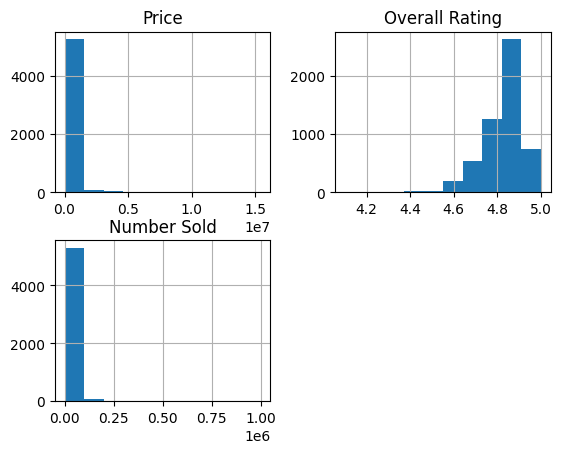

In [11]:
df_eda.hist(column=["Price", "Overall Rating", "Number Sold"])

Price, dan Number Sold memiliki skewness

In [12]:
corr_matrix = df_eda.corr(numeric_only=True)

In [13]:
corr_matrix["Number Sold"].sort_values(ascending=False)

Number Sold        1.000000
Total Review       0.168996
Overall Rating     0.010868
Price             -0.048139
Customer Rating   -0.061388
Name: Number Sold, dtype: float64

rata-rata rating (Overall Rating) memiliki korelasi tinggi dengan Number Sold. 
Begitupun dengan price, meskipun negatif korelasinya, artinya semakin kecil Price 
semakin banyak pembelinya, yang sangat masuk akal jika kita consider buying power di Indonesia

<Axes: xlabel='Overall Rating', ylabel='Number Sold'>

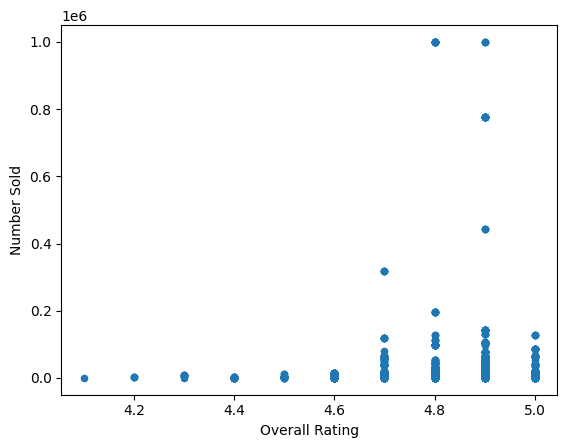

In [14]:
df_eda.plot(kind="scatter", x="Overall Rating", y="Number Sold")

<Axes: xlabel='Price', ylabel='Number Sold'>

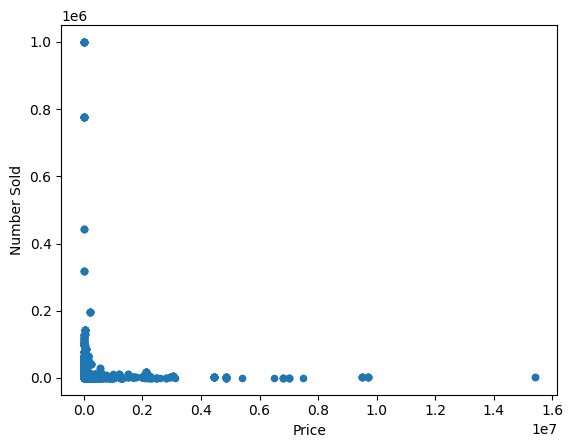

In [15]:
df_eda.plot(kind="scatter", x="Price", y="Number Sold")

# Data Pre-Processing

In [16]:
print(strat_train_set.columns)

Index(['Category', 'Product Name', 'Location', 'Price', 'Overall Rating',
       'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review',
       'Sentiment', 'Emotion'],
      dtype='str')


In [17]:
df = copy.deepcopy(strat_train_set)
df = df.drop(strat_train_set.columns[1:3], axis=1)
df = df.drop(strat_train_set.columns[6:], axis=1)
# df_label = copy.deepcopy(strat_train_set)
# df_label =  df_label.loc[:, "Number Sold"]


In [18]:
df.head()

,Category,Price,Overall Rating,Number Sold
4201,Kids and Baby Fashion,9000,4.9,15200
4055,Kitchen,359000,4.9,3890
1474,Party Supplies and Craft,7900,4.8,19800
1309,Body Care,72300,5.0,9695
2917,Men's Fashion,149000,4.9,1413


In [19]:
df.info()

<class 'pandas.DataFrame'>
Index: 4320 entries, 4201 to 4958
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        4320 non-null   str    
 1   Price           4320 non-null   int64  
 2   Overall Rating  4320 non-null   float64
 3   Number Sold     4320 non-null   int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 168.8 KB


In [20]:
display(df.isnull().sum())


Category          0
Price             0
Overall Rating    0
Number Sold       0
dtype: int64

<Axes: >

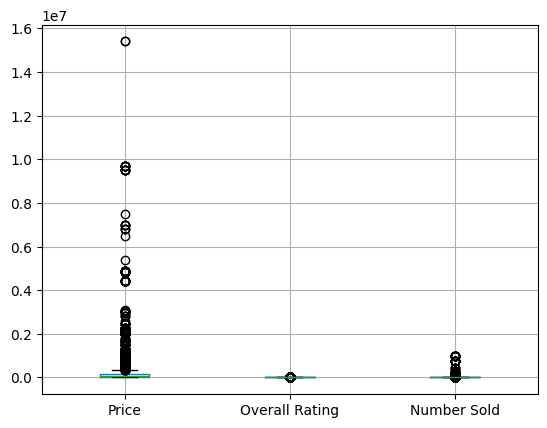

In [21]:
df.boxplot()

In [22]:
from sklearn.preprocessing import PowerTransformer
import pandas as pd


pt = PowerTransformer(method='yeo-johnson', standardize=True)


cols_to_fix = ['Price', 'Number Sold']
df[cols_to_fix] = pt.fit_transform(df[cols_to_fix])


<Axes: >

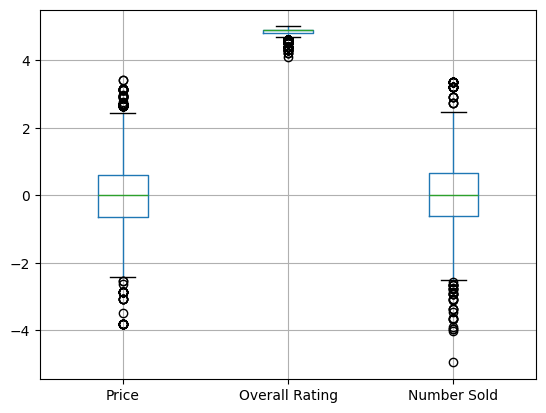

In [23]:
df.boxplot()

In [24]:
df.head()

,Category,Price,Overall Rating,Number Sold
4201,Kids and Baby Fashion,-1.133415,4.9,0.942614
4055,Kitchen,1.103796,4.9,0.025900
1474,Party Supplies and Craft,-1.211866,4.8,1.112240
1309,Body Care,0.126698,5.0,0.648081
2917,Men's Fashion,0.566754,4.9,-0.703414


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('scaling', StandardScaler(), [1, 2]),
        ('scaling_label', StandardScaler(), [-1]),
        ('cat', OneHotEncoder(sparse_output=False), [0]),
    ],
    remainder='passthrough' ,
    verbose_feature_names_out=False
)

data_transformed = preprocessor.fit_transform(df)

df_final = pd.DataFrame(
    data_transformed, 
    columns=preprocessor.get_feature_names_out()
)

In [26]:
df_final

,Price,Overall Rating,Number Sold,Category_Animal Care,Category_Automotive,Category_Beauty,Category_Body Care,Category_Books,Category_Camera,Category_Carpentry,...,Category_Office & Stationery,Category_Other Products,Category_Party Supplies and Craft,Category_Phones and Tablets,Category_Precious Metal,Category_Property,Category_Sport,Category_Tour and Travel,Category_Toys and Hobbies,Category_Women's Fashion
0,-1.133415,0.420907,0.942614,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.103796,0.420907,0.025900,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.211866,-0.503504,1.112240,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.126698,1.345317,0.648081,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.566754,0.420907,-0.703414,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4315,-0.240107,-0.503504,-1.091975,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4316,-0.396701,-1.427915,-0.206251,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4317,1.407077,1.345317,-0.439389,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4318,0.422064,0.420907,0.046783,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df = df_final

In [28]:
df = df.rename(columns={"Price": "price", "Overall Rating": "overall_rating", "Number Sold": "number_sold"})

In [29]:
df.head()

,price,overall_rating,number_sold,Category_Animal Care,Category_Automotive,Category_Beauty,Category_Body Care,Category_Books,Category_Camera,Category_Carpentry,...,Category_Office & Stationery,Category_Other Products,Category_Party Supplies and Craft,Category_Phones and Tablets,Category_Precious Metal,Category_Property,Category_Sport,Category_Tour and Travel,Category_Toys and Hobbies,Category_Women's Fashion
0,-1.133415,0.420907,0.942614,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.103796,0.420907,0.025900,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.211866,-0.503504,1.112240,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.126698,1.345317,0.648081,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.566754,0.420907,-0.703414,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
